
--- Mean de/dl per Volume ---
Tissue: 197.501793
Detector3: 3118.323206


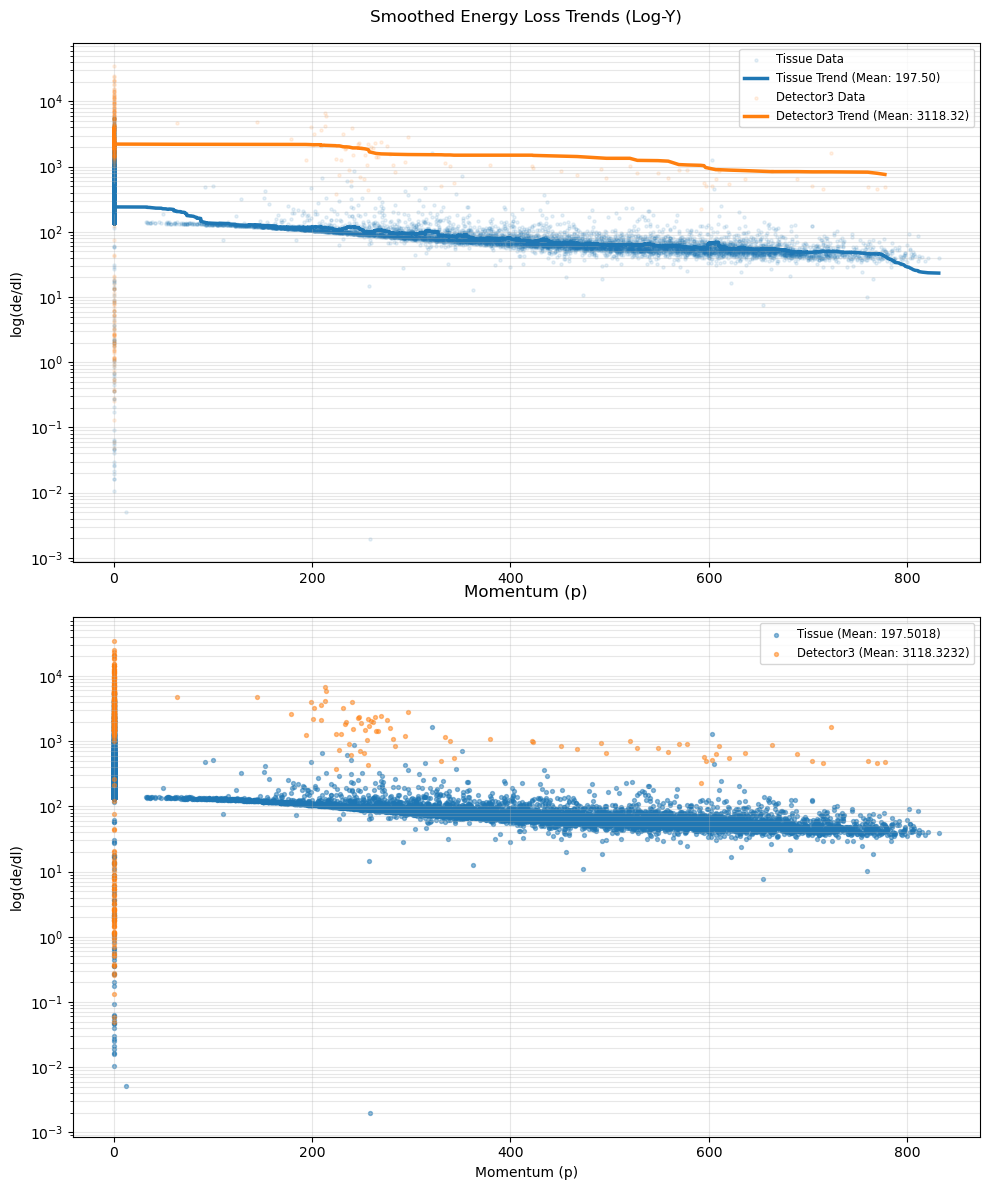

In [12]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "phantom.root"

# Volume labels
vlm_labels = {
    2: "Tissue",
    3: "Tumor",
    6: "Detector3"
}

# Helper function for smoothing
def smooth_data(x, y, window_size=150):
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]
    window = np.ones(window_size) / window_size
    y_smooth = np.convolve(y_sorted, window, mode='same')
    return x_sorted, y_smooth

# Data Loading
with uproot.open(file_path) as f:
    tree = f["t"]
    de = np.concatenate(tree["de"].array(library="np")).ravel()
    dl = np.concatenate(tree["dl"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()
    p = np.concatenate(tree["p"].array(library="np")).ravel()

# Create two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Dictionary to store results for console output
mean_results = {}

for v in [2, 3, 6]:
    mask = (vlm == v) & (dl > 0) & (de > 0)
    p_v = p[mask]
    dedl_v = de[mask] / dl[mask]
    
    if len(dedl_v) == 0: continue

    # Calculate mean value
    mean_val = np.mean(dedl_v)
    mean_results[vlm_labels[v]] = mean_val

    # FIG 1: Scatter (faint) + Smoothed Trend Line
    ax1.scatter(p_v, dedl_v, s=5, alpha=0.1, label=f"{vlm_labels[v]} Data")
    x_c, y_c = smooth_data(p_v, dedl_v)
    ax1.plot(x_c, y_c, linewidth=2.5, label=f"{vlm_labels[v]} Trend (Mean: {mean_val:.2f})")

    # FIG 2: Standard Scatter Plot
    ax2.scatter(p_v, dedl_v, s=8, alpha=0.5, label=f"{vlm_labels[v]} (Mean: {mean_val:.4f})")

# Print the mean values to the console (as requested)
print("\n--- Mean de/dl per Volume ---")
for label, value in mean_results.items():
    print(f"{label}: {value:.6f}")

# Formatting both plots
for ax in [ax1, ax2]:
    ax.set_yscale("log") # Log scale for Y on both figures
    ax.set_ylabel("log(de/dl)")
    ax.legend(loc='upper right', frameon=True, fontsize='small')
    ax.grid(True, which="both", alpha=0.3)

ax1.set_title("Smoothed Energy Loss Trends (Log-Y)", pad=15)
ax2.set_xlabel("Momentum (p)")
ax2.set_title("Momentum (p)", pad=15)

plt.tight_layout()
ax1.tick_params(labelbottom=True)
plt.show()